<a href="https://colab.research.google.com/github/adrianegonaves/introduction-to-artificial-intelligence-project/blob/master/introduction_to_artificial_intelligence_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto - Introdução à Inteligência Artificial

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
msambare_fer2013_path = kagglehub.dataset_download('msambare/fer2013')

print('Data source import complete.')


Using Colab cache for faster access to the 'fer2013' dataset.
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/fer2013/train/happy/Training_71717074.jpg
/kaggle/input/fer2013/train/happy/Training_83349364.jpg
/kaggle/input/fer2013/train/happy/Training_8224205.jpg
/kaggle/input/fer2013/train/happy/Training_69103613.jpg
/kaggle/input/fer2013/train/happy/Training_7098848.jpg
/kaggle/input/fer2013/train/happy/Training_38129729.jpg
/kaggle/input/fer2013/train/happy/Training_95151390.jpg
/kaggle/input/fer2013/train/happy/Training_66874071.jpg
/kaggle/input/fer2013/train/happy/Training_23294249.jpg
/kaggle/input/fer2013/train/happy/Training_86508875.jpg
/kaggle/input/fer2013/train/happy/Training_50691325.jpg
/kaggle/input/fer2013/train/happy/Training_26593901.jpg
/kaggle/input/fer2013/train/happy/Training_81451115.jpg
/kaggle/input/fer2013/train/happy/Training_39982194.jpg
/kaggle/input/fer2013/train/happy/Training_18980574.jpg
/kaggle/input/fer2013/train/happy/Training_39446205.jpg
/kaggle/input/fer2013/train/happy/Training_9457008.jpg


# Pré-**processamento**

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_19680/2427359914.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


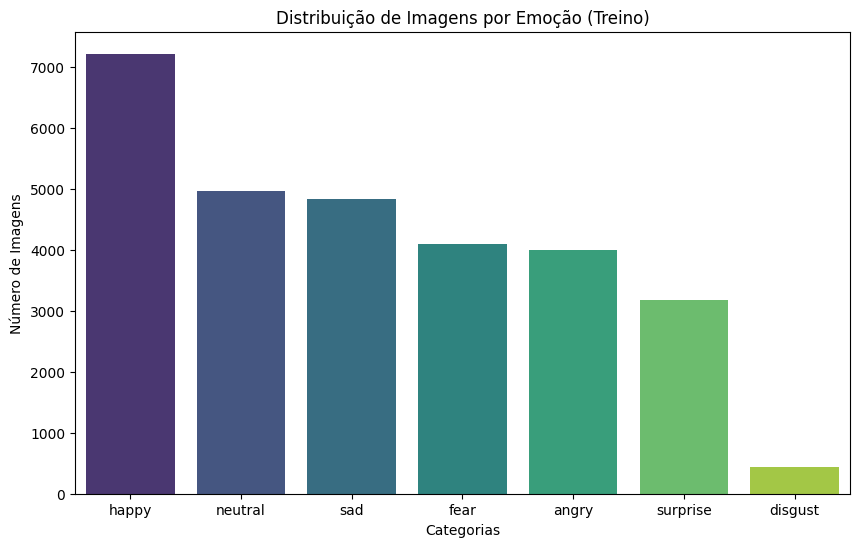

Happy: 7215 imagens
Neutral: 4965 imagens
Sad: 4830 imagens
Fear: 4097 imagens
Angry: 3995 imagens
Surprise: 3171 imagens
Disgust: 436 imagens


In [4]:

# Defina o caminho para a pasta de treino
base_path = "/kaggle/input/fer2013/train/"

# Dicionário para guardar as contagens
counts = {}

# Percorre cada subpasta (cada emoção)
for emotion in os.listdir(base_path):
    emotion_path = os.path.join(base_path, emotion)
    if os.path.isdir(emotion_path):
        # Conta quantos arquivos tem dentro da pasta daquela emoção
        counts[emotion] = len(os.listdir(emotion_path))

# Ordenar para o gráfico ficar mais bonito
counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True))

# Criar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
plt.title("Distribuição de Imagens por Emoção (Treino)")
plt.ylabel("Número de Imagens")
plt.xlabel("Categorias")
plt.show()

# Imprimir os valores exatos
for emotion, count in counts.items():
    print(f"{emotion.capitalize()}: {count} imagens")

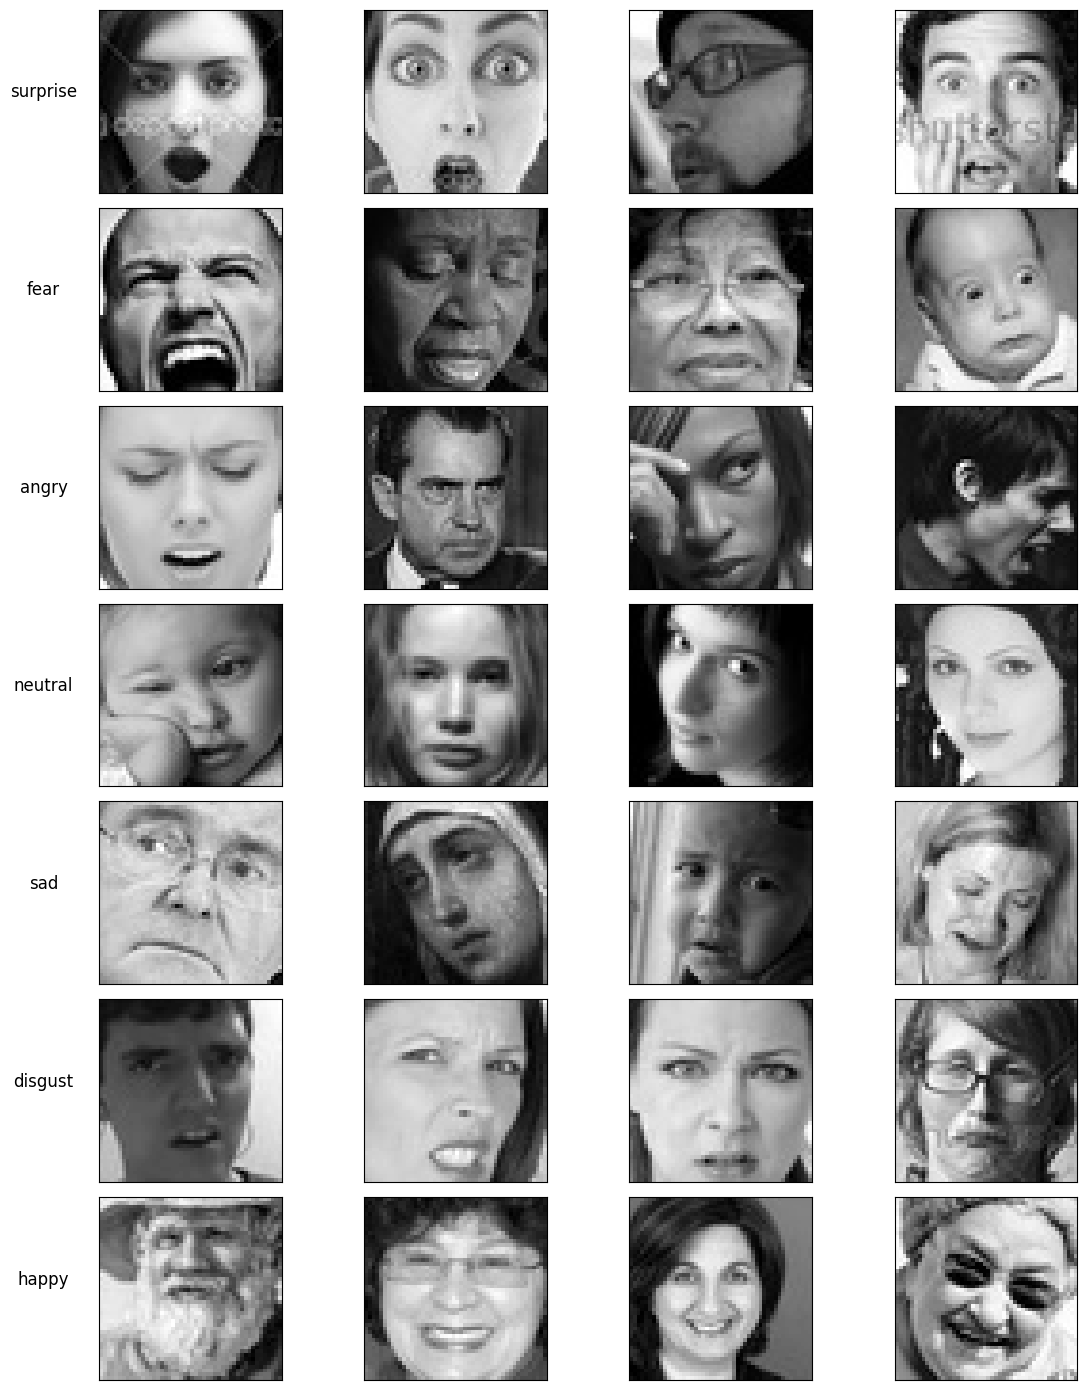

In [6]:
import matplotlib.pyplot as plt
import os

# 1. Ajuste o caminho base para a pasta 'train'
base_path = "/kaggle/input/fer2013/train"
# Certifique-se de que 'categorias' está definida (ex: os nomes das pastas de emoções)
categorias = os.listdir(base_path)
n_exemplos = 4 # <--- Definido com "o"

plt.figure(figsize=(12, 14))
contador = 1

for emotion in categorias:
    folder_path = os.path.join(base_path, emotion)
    img_names = os.listdir(folder_path)[:n_exemplos]

    for i, img_name in enumerate(img_names):
        img_path = os.path.join(folder_path, img_name)
        img = plt.imread(img_path)

        # CORREÇÃO AQUI: n_exemplos (com "o") para bater com a definição acima
        plt.subplot(len(categorias), n_exemplos, contador)

        plt.imshow(img, cmap='gray')

        if i == 0:
            plt.ylabel(emotion, fontsize=12, rotation=0, labelpad=40)

        plt.xticks([])
        plt.yticks([])

        contador += 1

plt.tight_layout()
plt.show()

In [9]:
from tensorflow import keras
base_path = "/kaggle/input/fer2013/train"

val_ds = keras.utils.image_dataset_from_directory(
    directory=base_path,
    image_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    label_mode="categorical",
    labels="inferred",
    validation_split=0.2,
    subset="validation",
    seed=50
)

train_ds = keras.utils.image_dataset_from_directory(
    directory=base_path,
    image_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    label_mode="categorical",
    labels="inferred",
    validation_split= 0.2,
    subset="training",
    seed=50
)

Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 28709 files belonging to 7 classes.
Using 22968 files for training.
